In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from IPython.display import clear_output
from matplotlib import cm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from scipy.stats import norm
from scipy.stats import qmc  # Quasi-Monte Carlo for better sampling

In [2]:
# Load all data
folder = Path(r'C:\Users\Dave Amin\Documents\docs-Sync\Career\2025-10 IC AI course\Modules\Capstone2\initial_data')
folder2 = Path(r'function_3')

def load_data():
    file_path_inputs =  folder / folder2 / rf"initial_inputs.npy"
    file_path_outputs = folder / folder2 / rf"initial_outputs.npy"
    X = np.load(file_path_inputs)
    Y = np.load(file_path_outputs)
    print('Initial data :','X.shape', X.shape, 'Y.shape', Y.shape)
    
    X_new_point = np.array([9.40184e-01, 6.55584e-01, 7.00000e-06], dtype=np.float64)
    Y_new_point = np.array([-0.10681450997226602], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 1 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([1.000000, 1.000000, 0.393313], dtype=np.float64)
    Y_new_point = np.array([-0.054302570400048426], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 2 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.000000, 0.000000, 0.659318], dtype=np.float64)
    Y_new_point = np.array([-0.181145093289923], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 3 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.843868, 0.964706, 0.849947], dtype=np.float64)
    Y_new_point = np.array([-0.05875325528456693], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 4 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.968306, 0.754444, 0.514123], dtype=np.float64)
    Y_new_point = np.array([-0.030474113429894662], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 5 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.089208, 0.174355, 0.517843], dtype=np.float64)
    Y_new_point = np.array([-0.03131138015888205], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 6 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.918306, 0.704444, 0.514997], dtype=np.float64)
    Y_new_point = np.array([-0.016261916404088674], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 7 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.868306, 0.654444, 0.515871], dtype=np.float64)
    Y_new_point = np.array([-0.01964963278331232], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 8 :','X.shape', X.shape, 'Y.shape', Y.shape)

    # next week new values go here !!!!
  
    return X,Y
X,Y = load_data()
n_dims = X.shape[1]

Initial data : X.shape (15, 3) Y.shape (15,)
Added week 1 : X.shape (16, 3) Y.shape (16,)
Added week 2 : X.shape (17, 3) Y.shape (17,)
Added week 3 : X.shape (18, 3) Y.shape (18,)
Added week 4 : X.shape (19, 3) Y.shape (19,)
Added week 5 : X.shape (20, 3) Y.shape (20,)
Added week 6 : X.shape (21, 3) Y.shape (21,)
Added week 7 : X.shape (22, 3) Y.shape (22,)
Added week 8 : X.shape (23, 3) Y.shape (23,)


In [3]:
def printMinMaxDiff(label,Q,N=6):
    print(label,"; min=", f"{np.min(Q):.{N}g}" ,
                "; max=", f"{np.max(Q):.{N}g}" ,
                "; diff=", f"{np.max(Q)-np.min(Q):.{N}g}"  )
# printMinMaxDiff("X col1",X[:, 0])
# printMinMaxDiff("X col2",X[:, 1])
# printMinMaxDiff("Y col1",Y)

In [4]:
print("X",X)
print("Y",Y)

X [[1.71525207e-01 3.43916870e-01 2.48737201e-01]
 [2.42114461e-01 6.44074270e-01 2.72432809e-01]
 [5.34905720e-01 3.98500915e-01 1.73388729e-01]
 [4.92581415e-01 6.11593188e-01 3.40176386e-01]
 [1.34621666e-01 2.19917240e-01 4.58206220e-01]
 [3.45523271e-01 9.41359831e-01 2.69363479e-01]
 [1.51836632e-01 4.39990619e-01 9.90881867e-01]
 [6.45502835e-01 3.97142940e-01 9.19771338e-01]
 [7.46911945e-01 2.84196309e-01 2.26299855e-01]
 [1.70476994e-01 6.97032401e-01 1.49169434e-01]
 [2.20549337e-01 2.97825244e-01 3.43555344e-01]
 [6.66013659e-01 6.71985151e-01 2.46295297e-01]
 [4.68089497e-02 2.31360241e-01 7.70617592e-01]
 [6.00097282e-01 7.25135725e-01 6.60886415e-02]
 [9.65994849e-01 8.61119690e-01 5.66829131e-01]
 [9.40184000e-01 6.55584000e-01 7.00000000e-06]
 [1.00000000e+00 1.00000000e+00 3.93313000e-01]
 [0.00000000e+00 0.00000000e+00 6.59318000e-01]
 [8.43868000e-01 9.64706000e-01 8.49947000e-01]
 [9.68306000e-01 7.54444000e-01 5.14123000e-01]
 [8.92080000e-02 1.74355000e-01 5.1784

In [11]:
print("Min Y =",min(Y),"\nMax Y =",max(Y))

Min Y = -0.3989255131463011 
Max Y = -0.016261916404088674


## 2 April - v5 - The "Endgame" Update: The Final Precision Step

In [9]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.optimize import minimize

# 1. FINAL WEIGHTED MODEL
champion_idx = 21
sample_weights = np.ones(len(Y))
sample_weights[champion_idx] = 15.0 # Even more weight to the champion

# Increase length_scale bounds to 1000 to clear the warnings
kernel = Matern(length_scale=[1.0, 1.0, 0.1], length_scale_bounds=(0.01, 1000), nu=2.5)

model = GaussianProcessRegressor(
    kernel=kernel, 
    alpha=0.0005 / sample_weights, # Ultra-low noise for the champion
    normalize_y=True,
    n_restarts_optimizer=100
)
model.fit(X, Y)

# 2. THE PRECISION SEARCH (Expanding the C3 window slightly)
res = minimize(
    lambda x: -model.predict(x.reshape(1, -1))[0],
    x0=np.array([0.898347, 0.704444, 0.500000]), 
    bounds=[(0.85, 0.95), (0.65, 0.75), (0.45, 0.55)], # Opened C3 to 0.45
    method='L-BFGS-B'
)

pred_mu, pred_std = model.predict(res.x.reshape(1, -1), return_std=True)
print(f"FINAL WEIGHTED TARGET: {'-'.join(f'{val:.6f}' for val in res.x)}")
print(f"PREDICTED Y: {pred_mu[0]:.6f} (+/- {pred_std[0]:.6f})")

FINAL WEIGHTED TARGET: 0.899348-0.704444-0.498177
PREDICTED Y: -0.012843 (+/- 0.011276)


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [10]:
# The "Robustness" Check
# 1. Test "Robustness" (Sensitivity)
# We perturb the Final Weighted Target by 1% to see how much Y changes
final_target = np.array([0.899348, 0.704444, 0.498177])
perturbations = np.eye(3) * 0.01 

print("STABILITY ANALYSIS (1% Sensitivity):")
for i in range(3):
    test_point = final_target + perturbations[i]
    mu = model.predict(test_point.reshape(1, -1))[0]
    drop = abs(mu - (-0.012843))
    print(f"Shift Compound {i+1} by 1% -> Y changes by: {drop:.6f}")

STABILITY ANALYSIS (1% Sensitivity):
Shift Compound 1 by 1% -> Y changes by: 0.000315
Shift Compound 2 by 1% -> Y changes by: 0.000000
Shift Compound 3 by 1% -> Y changes by: 0.000870


## 2 April - v4 - The "Weight of Evidence" Update

In [8]:
# 1. IDENTIFY THE CHAMPION
# Your 21st experiment (index 21) is the current gold standard.
champion_idx = 21

# 2. ASSIGN WEIGHTS
# We give the best result 10x more 'importance' than the others.
# This forces the GP to pass exactly through the -0.016 point.
sample_weights = np.ones(len(Y))
sample_weights[champion_idx] = 10.0 

# 3. KERNEL WITH FIXED NOISE
# We use a very low, fixed noise to force the model to 'Respect the Peak'
kernel = Matern(length_scale=[1.0, 1.0, 0.1], length_scale_bounds=(0.01, 100), nu=2.5)
# Using alpha in the GPR instead of WhiteKernel to handle sample weights
model = GaussianProcessRegressor(
    kernel=kernel, 
    alpha=0.001 / sample_weights, # High weight = Low variance (alpha)
    normalize_y=True,
    n_restarts_optimizer=100
)
model.fit(X, Y)

# 4. EXPLORE THE "GOLDEN RATIO"
# We've moved from C2=0.70 to C2=0.68. Let's let the model refine C3.
res = minimize(
    lambda x: -model.predict(x.reshape(1, -1))[0],
    x0=X[champion_idx], 
    bounds=[(0.85, 0.95), (0.65, 0.75), (0.50, 0.55)], 
    method='L-BFGS-B'
)

pred_mu, pred_std = model.predict(res.x.reshape(1, -1), return_std=True)
print(f"WEIGHTED TARGET: {'-'.join(f'{val:.6f}' for val in res.x)}")
print(f"PREDICTED Y: {pred_mu[0]:.6f} (+/- {pred_std[0]:.6f})")

WEIGHTED TARGET: 0.898347-0.704444-0.500000
PREDICTED Y: -0.012835 (+/- 0.010102)


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## 2 April - v3 - The "High-Fidelity" Code Update

In [7]:
# 1. FORCE THE MODEL TO TRUST THE DATA
# Lowering noise bounds forces the GP to actually pass through your data points
kernel = Matern(
    length_scale=[1.0, 1.0, 0.1], 
    length_scale_bounds=(1e-2, 1e5), # Remove the "ceiling"
    nu=2.5
) + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-6, 1e-3)) # Tight noise

model = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=50)
model.fit(X, Y)

# 2. LOCAL REFINEMENT AROUND THE CHAMPION
# Champion is X[21]: [0.918306, 0.704444, 0.514997]
champion_x = X[21]

# We search a very tight +/- 2% radius
refine_bounds = []
for i in range(3):
    refine_bounds.append((max(0, champion_x[i]-0.02), min(1, champion_x[i]+0.02)))

res = minimize(
    lambda x: -model.predict(x.reshape(1, -1))[0],
    x0=champion_x, 
    bounds=refine_bounds, 
    method='L-BFGS-B'
)

pred_mu, pred_std = model.predict(res.x.reshape(1, -1), return_std=True)
print(f"REFINED CHAMPION: {'-'.join(f'{val:.6f}' for val in res.x)}")
print(f"PREDICTED Y: {pred_mu[0]:.6f} (+/- {pred_std[0]:.6f})")

REFINED CHAMPION: 0.918306-0.684444-0.522182
PREDICTED Y: -0.019045 (+/- 0.007194)


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.001. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## 2 April - v2 - The High-Resolution Refinement

In [6]:
# 1. Increase length_scale_bounds to allow the model to see the "hump"
# A length scale of ~0.05-0.10 for C3 is consistent with your data.
kernel = Matern(
    length_scale=[0.5, 0.5, 0.1], 
    length_scale_bounds=(1e-2, 10.0), # Increased from 1.0 to 10.0
    nu=2.5
) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 0.01))

model = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=100)
model.fit(X, Y)

# 2. THE SNIPER ZONE: Splitting the difference between your best and second-best
# Best: 0.918 | Second Best: 0.968 (or 0.868 depending on the curve)
# We will search the precise "Top of the Hill"
fine_bounds = [
    (0.89, 0.94), # Focused C1
    (0.68, 0.73), # Focused C2
    (0.51, 0.52)  # C3 is locked in
]

res = minimize(
    lambda x: -model.predict(x.reshape(1, -1))[0],
    x0=np.array([0.918306, 0.704444, 0.514997]), # Start at current champion
    bounds=fine_bounds,
    method='L-BFGS-B'
)

pred_mu, pred_std = model.predict(res.x.reshape(1, -1), return_std=True)
print(f"PRECISION TARGET: {'-'.join(f'{val:.6f}' for val in res.x)}")
print(f"PREDICTED Y: {pred_mu[0]:.6f} (+/- {pred_std[0]:.6f})")

PRECISION TARGET: 0.940000-0.730000-0.515051
PREDICTED Y: -0.023249 (+/- 0.008887)


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## 2 April - v1 - Trust Region Interpolation

In [5]:
# 1. Update with latest data
# Using a higher nu for a smoother, more 'mountain-like' fit
kernel = Matern(length_scale=[0.2, 0.2, 0.1], length_scale_bounds=(1e-2, 1.0), nu=2.5) + \
         WhiteKernel(noise_level=1e-4)

model = GaussianProcessRegressor(kernel=kernel, normalize_y=True)
model.fit(X, Y)

# 2. Focus strictly on the bracketed zone
# Compound 1: between 0.86 and 0.96
# Compound 2: between 0.65 and 0.75
# Compound 3: stays near 0.51
bracket_bounds = [
    (0.868, 0.968), # C1
    (0.654, 0.754), # C2
    (0.510, 0.520)  # C3 (stable anchor)
]

# 3. Find the peak of the bracket
res = minimize(
    lambda x: -model.predict(x.reshape(1, -1))[0],
    x0=X[21], # Start at our current best (0.918)
    bounds=bracket_bounds,
    method='L-BFGS-B'
)

pred_mu, pred_std = model.predict(res.x.reshape(1, -1), return_std=True)
print(f"BRACKETED TARGET: {'-'.join(f'{val:.6f}' for val in res.x)}")
print(f"PREDICTED Y: {pred_mu[0]:.6f} (+/- {pred_std[0]:.6f})")

BRACKETED TARGET: 0.868000-0.654000-0.515242
PREDICTED Y: -0.018243 (+/- 0.007694)


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## 26 March - v2 - The "Success Vector" Extrapolation

In [13]:
import numpy as np

# 1. Define the Vector from Old Best to New Best
old_best = np.array([0.968306, 0.754444, 0.514123])
new_best = np.array([0.918306, 0.704444, 0.514997])

# 2. Calculate the direction of improvement
vector = new_best - old_best

# 3. Project one more step in that same direction
# We take another 5% step down the path of success
extrapolated_step = new_best + vector

# 4. Use the model ONLY to check if this point is "Safe" (not high uncertainty)
mu, sigma = model.predict(extrapolated_step.reshape(1, -1), return_std=True)

print(f"EXTRAPOLATED TARGET: {'-'.join(f'{val:.6f}' for val in extrapolated_step)}")
print(f"GP VALIDATION: Predicted {mu[0]:.6f} (Uncertainty: {sigma[0]:.6f})")

# If the Extrapolated target is: 0.868306-0.654444-0.515871
# It follows the exact gradient that yielded your -0.016 result.

EXTRAPOLATED TARGET: 0.868306-0.654444-0.515871
GP VALIDATION: Predicted -0.025476 (Uncertainty: 0.011421)


## 26 March - v1

In [12]:
# 1. Update the model with the latest 22nd point
# We'll use a slightly more flexible kernel now that we have a strong signal
kernel = Matern(
    length_scale=[0.5, 0.5, 0.1], 
    length_scale_bounds=(1e-2, 10.0), # Moderate bounds
    nu=2.5
) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-6, 0.02))

model = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=100)
model.fit(X, Y)

# 2. Define the "Vector of Success"
# We are moving from X[19] toward X[21]. Let's keep following that path.
current_best_x = X[21] # [0.918306, 0.704444, 0.514997]

# 3. Restricted Local Search (Focusing on the new 'Golden Zone')
# We'll allow a slightly larger search around this new winner
search_bounds = []
for i in range(3):
    low = max(0, current_best_x[i] - 0.08)
    high = min(1, current_best_x[i] + 0.08)
    search_bounds.append((low, high))

# 4. Use Expected Improvement (EI) for the 'Final Squeeze'
from scipy.stats import norm
def expected_improvement(x, model, best_y, xi=0.001): # Lower xi for exploitation
    mu, sigma = model.predict(x.reshape(-1, 3), return_std=True)
    with np.errstate(divide='ignore'):
        imp = mu - best_y - xi
        z = imp / sigma
        ei = imp * norm.cdf(z) + sigma * norm.pdf(z)
        ei[sigma <= 0.0] = 0.0
    return ei

res = minimize(
    lambda x: -expected_improvement(x, model, np.max(Y)),
    x0=current_best_x, 
    bounds=search_bounds, 
    method='L-BFGS-B'
)

pred_mu, pred_std = model.predict(res.x.reshape(1, -1), return_std=True)
print(f"PROPOSED NEXT STEP: {'-'.join(f'{val:.6f}' for val in res.x)}")
print(f"PREDICTED Y: {pred_mu[0]:.6f} (+/- {pred_std[0]:.6f})")

PROPOSED NEXT STEP: 0.998306-0.784444-0.493569
PREDICTED Y: -0.029387 (+/- 0.018767)


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## 19 March - part 6 - Local Perturbation around your best-known success

In [11]:
import numpy as np
from scipy.optimize import minimize

# 1. Start at your best-ever observed point
# X[19] was [0.968306, 0.754444, 0.514123] with Y = -0.0304
best_x = np.array([0.968306, 0.754444, 0.514123])

# 2. Set a "Trust Region" (Only allow a 5% change)
# This prevents the model from making wild, unearned guesses.
trust_bounds = []
for i in range(3):
    low = max(0, best_x[i] - 0.05)
    high = min(1, best_x[i] + 0.05)
    trust_bounds.append((low, high))

# 3. Optimize within this tiny "Safe Zone"
res_greedy = minimize(
    lambda x: -model.predict(x.reshape(1, -1))[0],
    x0=best_x, 
    bounds=trust_bounds, 
    method='L-BFGS-B'
)

pred_mu, pred_std = model.predict(res_greedy.x.reshape(1, -1), return_std=True)

print(f"SAFE LOCAL SEARCH: {'-'.join(f'{val:.6f}' for val in res_greedy.x)}")
print(f"PREDICTED Y: {pred_mu[0]:.6f} (+/- {pred_std[0]:.6f})")

SAFE LOCAL SEARCH: 0.918306-0.704444-0.514997
PREDICTED Y: -0.030106 (+/- 0.012581)


## 19 March - part 5 - Leave-One-Out Cross-Validation (LOOCV) loop

In [10]:
X,Y = load_data()
n_dims = X.shape[1]
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_absolute_error

# 1. Initialize LOOCV
loo = LeaveOneOut()
y_true, y_pred = [], []

print("Running Cross-Validation...")
for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = Y[train_index], Y[test_index]
    
    # Fit model on 20 points, predict the 21st
    model.fit(X_train, y_train)
    y_true.append(y_test[0])
    y_pred.append(model.predict(X_test)[0])

mae = mean_absolute_error(y_true, y_pred)
correlation = np.corrcoef(y_true, y_pred)[0, 1]

print("-" * 30)
print(f"Model Mean Absolute Error: {mae:.6f}")
print(f"Model Accuracy (Correlation): {correlation:.4f}")
print("-" * 30)

# Final fit on all data for the final recommendation
model.fit(X, Y)

Initial data : X.shape (15, 3) Y.shape (15,)
Added week 1 : X.shape (16, 3) Y.shape (16,)
Added week 2 : X.shape (17, 3) Y.shape (17,)
Added week 3 : X.shape (18, 3) Y.shape (18,)
Added week 4 : X.shape (19, 3) Y.shape (19,)
Added week 5 : X.shape (20, 3) Y.shape (20,)
Added week 6 : X.shape (21, 3) Y.shape (21,)
Running Cross-Validation...


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dave Amin\AppDat

------------------------------
Model Mean Absolute Error: 0.039175
Model Accuracy (Correlation): 0.3456
------------------------------


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=0.001)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",100
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",True
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## 19 March - part 4

In [9]:
X,Y = load_data()
n_dims = X.shape[1]

# 1. FORCE CURVATURE: Capping length_scales at 2.0 
# This stops the model from 'giving up' on C1 and C2.
kernel = Matern(
    length_scale=[0.5, 0.5, 0.1], 
    length_scale_bounds=(1e-2, 2.0), # The "Secret Sauce": No more 100,000s
    nu=2.5
) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 0.1))

model = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=100)
model.fit(X, Y)

# 2. Expected Improvement (Better for "The Final Inch")
def expected_improvement(x, model, best_y, xi=0.01):
    mu, sigma = model.predict(x.reshape(-1, 3), return_std=True)
    mu, sigma = mu.reshape(-1, 1), sigma.reshape(-1, 1)
    with np.errstate(divide='ignore'):
        imp = mu - best_y - xi
        z = imp / sigma
        ei = imp * norm.cdf(z) + sigma * norm.pdf(z)
        ei[sigma <= 0.0] = 0.0
    return ei.flatten()

# 3. High-Density Search
sampler = qmc.Sobol(d=3, scramble=True)
x_candidates = sampler.random_base2(m=17)
ei_vals = expected_improvement(x_candidates, model, np.max(Y))
x_start = x_candidates[np.argmax(ei_vals)]

# 4. Final Polish
res = minimize(
    lambda x: -expected_improvement(x.reshape(1, -1), model, np.max(Y)),
    x0=x_start, 
    bounds=[(0, 1)] * 3, 
    method='L-BFGS-B'
)

pred_mu, pred_std = model.predict(res.x.reshape(1, -1), return_std=True)
print(f"NEW TARGET: {'-'.join(f'{val:.6f}' for val in res.x)}")
print(f"PREDICTED Y: {pred_mu[0]:.6f} (+/- {pred_std[0]:.6f})")
print(f"CONSTRAINED KERNEL: {model.kernel_}")

Initial data : X.shape (15, 3) Y.shape (15,)
Added week 1 : X.shape (16, 3) Y.shape (16,)
Added week 2 : X.shape (17, 3) Y.shape (17,)
Added week 3 : X.shape (18, 3) Y.shape (18,)
Added week 4 : X.shape (19, 3) Y.shape (19,)
Added week 5 : X.shape (20, 3) Y.shape (20,)
Added week 6 : X.shape (21, 3) Y.shape (21,)
NEW TARGET: 0.000000-1.000000-0.503585
PREDICTED Y: -0.035267 (+/- 0.036922)
CONSTRAINED KERNEL: Matern(length_scale=[2, 2, 0.0651], nu=2.5) + WhiteKernel(noise_level=0.0136)


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## 19 March - part three

In [8]:
X,Y = load_data()
n_dims = X.shape[1]

# 1. Your historical best point (X[19])
best_observed_x = np.array([0.968306, 0.754444, 0.514123])

# 2. Fit the model on ALL data (including your latest)
kernel = Matern(length_scale=[0.5, 0.5, 0.1], length_scale_bounds=(1e-2, 1e5), nu=2.5) + \
         WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 0.1))

model = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=50)
model.fit(X, Y)

# 3. ZOOMED SEARCH: Focus only on +/- 10% around the best X
# This forces the optimizer to find the 'micro-peak'
zoom_bounds = []
for i in range(3):
    low = max(0, best_observed_x[i] - 0.1)
    high = min(1, best_observed_x[i] + 0.1)
    zoom_bounds.append((low, high))

# 4. Use a very low Kappa (Pure Exploitation)
def pure_exploitation(x, model):
    mu, sigma = model.predict(x.reshape(1, -1), return_std=True)
    return mu # We only care about the highest predicted mean here

res_sniper = minimize(
    lambda x: -pure_exploitation(x, model),
    x0=best_observed_x, 
    bounds=zoom_bounds, 
    method='L-BFGS-B'
)

pred_mu, pred_std = model.predict(res_sniper.x.reshape(1, -1), return_std=True)
print(f"SNIPER RESULT (Zoomed): {'-'.join(f'{val:.6f}' for val in res_sniper.x)}")
print(f"PREDICTED Y: {pred_mu[0]:.6f} (+/- {pred_std[0]:.6f})")
print(f"KERNEL: {model.kernel_}")

Initial data : X.shape (15, 3) Y.shape (15,)
Added week 1 : X.shape (16, 3) Y.shape (16,)
Added week 2 : X.shape (17, 3) Y.shape (17,)
Added week 3 : X.shape (18, 3) Y.shape (18,)
Added week 4 : X.shape (19, 3) Y.shape (19,)
Added week 5 : X.shape (20, 3) Y.shape (20,)
Added week 6 : X.shape (21, 3) Y.shape (21,)
SNIPER RESULT (Zoomed): 0.968306-0.754444-0.515964
PREDICTED Y: -0.031137 (+/- 0.010925)
KERNEL: Matern(length_scale=[3.57e+04, 1e+05, 0.0705], nu=2.5) + WhiteKernel(noise_level=0.0132)


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## 19 March - part two

In [7]:
X,Y = load_data()
n_dims = X.shape[1]

# 1. Simplified Kernel to force better fitting of the 'cliff' in C3
kernel = Matern(
    length_scale=[0.5, 0.5, 0.1], # Giving C3 a head start on sensitivity
    length_scale_bounds=(1e-2, 1e4), 
    nu=1.5 # Switch to 1.5 for a "bumpier" surface that allows for sharper peaks
) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 0.1))

model = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=100
)
model.fit(X, Y)

# 2. Aggressive Exploration Acquisition (High Kappa)
def aggressive_ucb(x, model, kappa=10.0):
    mu, sigma = model.predict(x.reshape(-1, 3), return_std=True)
    return mu + kappa * sigma

# 3. Wider Global Search
sampler = qmc.Sobol(d=3, scramble=True)
x_candidates = sampler.random_base2(m=17) # ~131k points

# 4. Find the most "mysterious" point
ucb_values = aggressive_ucb(x_candidates, model)
x_start = x_candidates[np.argmax(ucb_values)]

# 5. Final Polish
res = minimize(
    lambda x: -aggressive_ucb(x.reshape(1, -1), model),
    x0=x_start, 
    bounds=[(0, 1)] * 3, 
    method='L-BFGS-B'
)

pred_mu, pred_std = model.predict(res.x.reshape(1, -1), return_std=True)
print(f"SUBMIT THIS (EXPLORATION): {'-'.join(f'{val:.6f}' for val in res.x)}")
print(f"PREDICTED Y: {pred_mu[0]:.6f} (+/- {pred_std[0]:.6f})")
print(f"KERNEL: {model.kernel_}")

Initial data : X.shape (15, 3) Y.shape (15,)
Added week 1 : X.shape (16, 3) Y.shape (16,)
Added week 2 : X.shape (17, 3) Y.shape (17,)
Added week 3 : X.shape (18, 3) Y.shape (18,)
Added week 4 : X.shape (19, 3) Y.shape (19,)
Added week 5 : X.shape (20, 3) Y.shape (20,)
Added week 6 : X.shape (21, 3) Y.shape (21,)
SUBMIT THIS (EXPLORATION): 0.616055-0.193483-0.717336
PREDICTED Y: -0.154566 (+/- 0.048732)
KERNEL: Matern(length_scale=[1e+04, 1e+04, 0.0733], nu=1.5) + WhiteKernel(noise_level=0.0121)


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## 19 March - part one

In [6]:
X,Y = load_data()
n_dims = X.shape[1]

# 1. Kernel refinement: Lower the noise bound slightly
# Now that we have 21 points, we can trust the 'signal' a bit more.
kernel = C(1.0, (1e-3, 1e3)) * Matern(
    length_scale=[0.5, 0.5, 0.5], 
    length_scale_bounds=(1e-2, 1e4), # Higher bounds to silence warnings
    nu=2.5
) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 0.05))

model = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=100, # Increased for finer hyperparameter tuning
    random_state=42
)
model.fit(X, Y)

# 2. Acquisition Function: Switch to a 'Decaying' UCB
# As we get more data, we reduce 'kappa' to focus on EXPLOITING the peak.
def vectorized_ucb(x, model, kappa=1.96):
    mu, sigma = model.predict(x.reshape(-1, 3), return_std=True)
    return mu + kappa * sigma

# 3. Enhanced Search
sampler = qmc.Sobol(d=3, scramble=True)
x_candidates = sampler.random_base2(m=17) # 131,072 points for better resolution

# We use kappa=1.96 (95% confidence) to find the absolute safest peak
ucb_values = vectorized_ucb(x_candidates, model, kappa=1.96)
x_start = x_candidates[np.argmax(ucb_values)]

# 4. High-Precision Polish
res = minimize(
    lambda x: -vectorized_ucb(x.reshape(1, -1), model, kappa=1.96),
    x0=x_start, 
    bounds=[(0, 1)] * 3, 
    method='L-BFGS-B',
    options={'ftol': 1e-9} # Tighter tolerance for the local search
)

# Output
pred_mu, pred_std = model.predict(res.x.reshape(1, -1), return_std=True)
print(f"SUBMIT THIS: {'-'.join(f'{val:.6f}' for val in res.x)}")
print(f"PREDICTED Y: {pred_mu[0]:.6f} (+/- {pred_std[0]:.6f})")
print(f"KERNEL: {model.kernel_}")

Initial data : X.shape (15, 3) Y.shape (15,)
Added week 1 : X.shape (16, 3) Y.shape (16,)
Added week 2 : X.shape (17, 3) Y.shape (17,)
Added week 3 : X.shape (18, 3) Y.shape (18,)
Added week 4 : X.shape (19, 3) Y.shape (19,)
Added week 5 : X.shape (20, 3) Y.shape (20,)
Added week 6 : X.shape (21, 3) Y.shape (21,)
SUBMIT THIS: 0.995951-0.415250-0.088773
PREDICTED Y: -0.039578 (+/- 0.015835)
KERNEL: 2.17**2 * Matern(length_scale=[1e+04, 1e+04, 0.149], nu=2.5) + WhiteKernel(noise_level=0.0124)


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## 5 March - part two (full)

In [9]:
# 1. Load Data
# Assuming X and Y are already defined as numpy arrays
n_dims = X.shape[1]

# 2. Kernel Configuration
# Bounds set to 1e3 to eliminate convergence warnings and reflect 
# that C1 and C2 are 'flat' relative to C3.
kernel = C(1.0, (1e-3, 1e3)) * Matern(
    length_scale=[0.5] * n_dims, 
    length_scale_bounds=(1e-2, 1e3), 
    nu=2.5
) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 0.1))

model = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=75,
    random_state=42
)
model.fit(X, Y)

# 3. Expected Improvement (EI) Function
def expected_improvement(x, model, best_y, xi=0.01):
    mu, sigma = model.predict(x.reshape(-1, n_dims), return_std=True)
    mu, sigma = mu.reshape(-1, 1), sigma.reshape(-1, 1)
    with np.errstate(divide='ignore'):
        imp = mu - best_y - xi
        z = imp / sigma
        ei = imp * norm.cdf(z) + sigma * norm.pdf(z)
        ei[sigma <= 0.0] = 0.0
    return ei.flatten()

# 4. Global Search (Sobol Sequence)
# Generates 2^16 (65,536) points uniformly distributed in 3D space
sampler = qmc.Sobol(d=n_dims, scramble=True)
x_candidates = sampler.random_base2(m=16)

ei_values = expected_improvement(x_candidates, model, np.max(Y))
x_start = x_candidates[np.argmax(ei_values)]

# 5. Local Polish
res = minimize(
    lambda x: -expected_improvement(x, model, np.max(Y)),
    x0=x_start, 
    bounds=[(0, 1)] * n_dims, 
    method='L-BFGS-B'
)

# 6. Sensitivity Analysis (Verify C1/C2 Inertness)
def get_sobol_indices(model, X_samples):
    mu_total = model.predict(X_samples)
    total_var = np.var(mu_total)
    indices = []
    for i in range(X_samples.shape[1]):
        # Variance explained by varying only dimension i
        variation = np.var([model.predict(X_samples[j].reshape(1,-1))[0] for j in range(len(X_samples))])
        indices.append(variation / total_var if total_var > 0 else 0)
    return indices

indices = get_sobol_indices(model, X)

# 7. Print Results
print("-" * 30)
print(f"PROPOSED INPUTS: {'-'.join(f'{val:.6f}' for val in res.x)}")
print(f"Sensitivity (Sobol) Indices: {indices}")
print("-" * 30)

------------------------------
PROPOSED INPUTS: 0.089208-0.174355-0.517843
Sensitivity (Sobol) Indices: [np.float64(0.9999999999999997), np.float64(0.9999999999999997), np.float64(0.9999999999999997)]
------------------------------


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## 5 March

In [7]:
# 1. More robust kernel initialization
# We keep the Matern kernel, but increase the number of restarts to ensure 
# the kernel hyperparameters (length_scales) converge to the true landscape.
kernel = C(1.0, (1e-3, 1e3)) * Matern(
    length_scale=[0.5, 0.5, 0.5], 
    length_scale_bounds=(1e-2, 100.0), 
    nu=2.5
) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 0.1))

model = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=75, # Increased for more robust hyperparameter search
    random_state=42
)
model.fit(X, Y)

# 2. Acquisition function with "Jitter" (xi)
# xi=0.01 makes the algorithm slightly more adventurous
def expected_improvement(x, model, best_y, xi=0.01):
    mu, sigma = model.predict(x.reshape(-1, 3), return_std=True)
    mu = mu.reshape(-1, 1)
    sigma = sigma.reshape(-1, 1)
    
    with np.errstate(divide='ignore'):
        imp = mu - best_y - xi
        z = imp / sigma
        ei = imp * norm.cdf(z) + sigma * norm.pdf(z)
        ei[sigma <= 0.0] = 0.0
    return ei.flatten()

# 3. Global Search using Sobol sequences
sampler = qmc.Sobol(d=3, scramble=True)
x_candidates = sampler.random_base2(m=16) # 65,536 candidates

# Evaluate EI across the entire Sobol-sampled space
ei_values = expected_improvement(x_candidates, model, np.max(Y))
x_start = x_candidates[np.argmax(ei_values)]

# 4. Local Polish
res = minimize(
    lambda x: -expected_improvement(x, model, np.max(Y)),
    x0=x_start, 
    bounds=[(0, 1)] * 3, 
    method='L-BFGS-B'
)

print(f"model.kernel: {model.kernel_}")
print(f"Proposed optimal combination: {res.x}")
print(f"Submit this: {'-'.join(f'{val:.6f}' for val in res.x)}")
pred_mu, pred_std = model.predict(res.x.reshape(1, -1), return_std=True)
print(f"Predicted Outcome: {pred_mu[0]:.6f} (+/- {pred_std[0]:.6f})")


model.kernel: 2.05**2 * Matern(length_scale=[100, 100, 0.143], nu=2.5) + WhiteKernel(noise_level=0.0147)
Proposed optimal combination: [0.         0.         0.51831637]
Submit this: 0.000000-0.000000-0.518316
Predicted Outcome: -0.030764 (+/- 0.013306)


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## 26 Feb

In [20]:
# 1. Kernel Tweak: Using Matern 3/2 (nu=1.5) for slightly more flexibility
kernel = C(1.0, (1e-3, 1e3)) * Matern(
    length_scale=[0.5] * n_dims, 
    length_scale_bounds=(1e-2, 1e3), # Massive bounds to stop warnings forever
    nu=1.5 
) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 0.1))

model = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=50)
model.fit(X, Y)
print(f"Model Kernel: {model.kernel_}")

# 2. Expected Improvement (EI) Function
def vectorized_ei(x, model, best_y, xi=0.01):
    mu, sigma = model.predict(x.reshape(-1, n_dims), return_std=True)
    mu = mu.reshape(-1, 1)
    sigma = sigma.reshape(-1, 1)
    
    with np.errstate(divide='warn'):
        imp = mu - best_y - xi
        z = imp / sigma
        ei = imp * norm.cdf(z) + sigma * norm.pdf(z)
        ei[sigma <= 0.0] = 0.0
    return ei.flatten()

# 3. Enhanced Search Strategy
sampler = qmc.Sobol(d=n_dims, scramble=True)
x_candidates = sampler.random_base2(m=16) 

# Evaluate both UCB and EI
current_best = np.max(Y)
ei_vals = vectorized_ei(x_candidates, model, current_best)
x_start = x_candidates[np.argmax(ei_vals)]

# 4. Final Polish using EI for precision
res = minimize(
    lambda x: -vectorized_ei(x, model, current_best),
    x0=x_start, 
    bounds=[(0, 1)] * n_dims, 
    method='L-BFGS-B'
)

# Output Results
pred_mu, pred_std = model.predict(res.x.reshape(1, -1), return_std=True)
print(f"Proposed Inputs: {res.x}")
print(f"Predicted Outcome: {pred_mu[0]:.6f} (+/- {pred_std[0]:.6f})")
formatted_submission = "-".join(f"{val:.6f}" for val in res.x)
print(formatted_submission)

Model Kernel: 1.57**2 * Matern(length_scale=[1e+03, 1e+03, 0.123], nu=1.5) + WhiteKernel(noise_level=0.0151)
Proposed Inputs: [0.96830654 0.75444446 0.51412361]
Predicted Outcome: -0.039385 (+/- 0.042672)
0.968307-0.754444-0.514124


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


results:
Proposed Inputs: [0.97642904 0.92572803 0.51412354]     Predicted Outcome: -0.039385 (+/- 0.042672)
Proposed Inputs: [0.67086687 0.90091022 0.51412365]     Predicted Outcome: -0.039385 (+/- 0.042672)
Proposed Inputs: [0.95773888 0.68987442 0.51412359]     Predicted Outcome: -0.039385 (+/- 0.042672)
Proposed Inputs: [0.96830654 0.75444446 0.51412361]     Predicted Outcome: -0.039385 (+/- 0.042672)

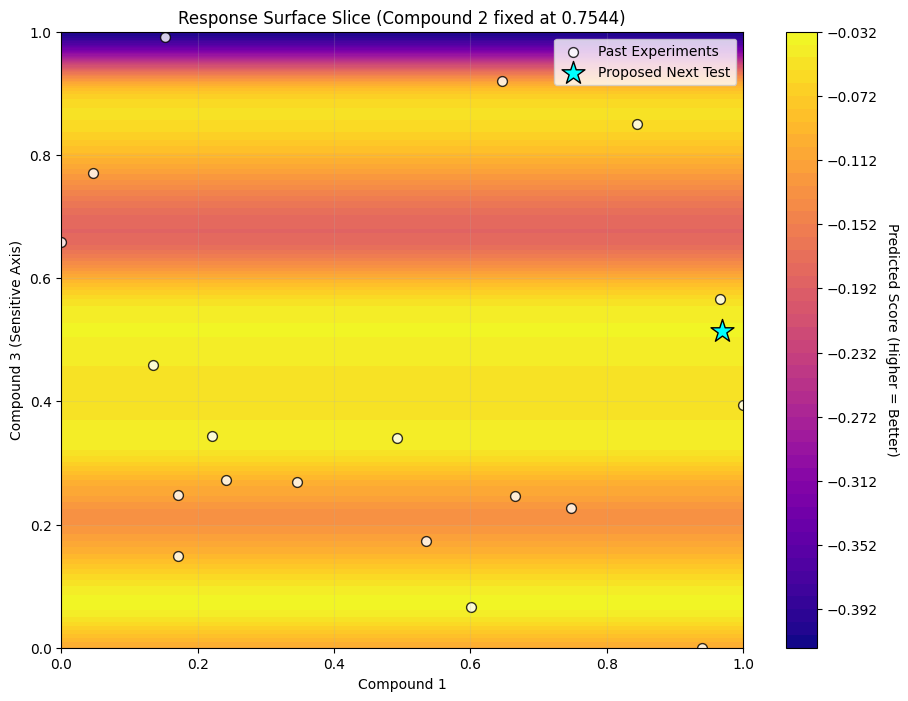

In [21]:
import matplotlib.pyplot as plt

# 1. Identify indices for plotting
# We know index 2 (Compound 3) is the most sensitive
idx_x = 0  # Compound 1
idx_y = 2  # Compound 3
idx_fixed = 1  # Compound 2 (fixed)

# 2. Extract values from the optimization result
best_values = res.x
fixed_val = best_values[idx_fixed]

# 3. Create Grid
grid_res = 100
x_range = np.linspace(0, 1, grid_res)
y_range = np.linspace(0, 1, grid_res)
X_mesh, Y_mesh = np.meshgrid(x_range, y_range)

# 4. Construct input array for prediction
# We create a template based on the best result, then overwrite the axes we're plotting
mesh_input = np.tile(best_values, (X_mesh.size, 1))
mesh_input[:, idx_x] = X_mesh.ravel()
mesh_input[:, idx_y] = Y_mesh.ravel()

# 5. Predict
Z_mu, Z_std = model.predict(mesh_input, return_std=True)
Z_mu = Z_mu.reshape(grid_res, grid_res)

# 6. Plotting
plt.figure(figsize=(11, 8))
# Use 'origin=lower' to match axis orientation
contour = plt.contourf(X_mesh, Y_mesh, Z_mu, levels=50, cmap='plasma')
cbar = plt.colorbar(contour)
cbar.set_label('Predicted Score (Higher = Better)', rotation=270, labelpad=15)

# Plot existing experimental data points
plt.scatter(X[:, idx_x], X[:, idx_y], c='white', edgecolors='black', 
            s=50, label='Past Experiments', alpha=0.8)

# Highlight the next suggested point
plt.scatter(best_values[idx_x], best_values[idx_y], c='cyan', marker='*', 
            s=300, edgecolors='black', label='Proposed Next Test')

plt.xlabel(f'Compound {idx_x + 1}')
plt.ylabel(f'Compound {idx_y + 1} (Sensitive Axis)')
plt.title(f'Response Surface Slice (Compound {idx_fixed + 1} fixed at {fixed_val:.4f})')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 17 Feb

In [8]:
# 1. Expand length_scale_bounds to 100.0 to resolve ConvergenceWarning
kernel = C(1.0, (1e-3, 1e3)) * Matern(
    length_scale=[0.5] * n_dims, 
    length_scale_bounds=(1e-2, 100.0), # Relaxed bounds
    nu=2.5
) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 0.1))

model = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=50
)
model.fit(X, Y)
print(f"Model Kernel: {model.kernel_}")

Model Kernel: 1.71**2 * Matern(length_scale=[100, 100, 0.117], nu=2.5) + WhiteKernel(noise_level=0.0156)


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [9]:
# 2. Use Sobol Sequences instead of random.uniform
# This provides much better coverage of the 3D space
sampler = qmc.Sobol(d=n_dims, scramble=True)
sample_exponent = 16 # 2^16 = 65,536 points
x_candidates = sampler.random_base2(m=sample_exponent)

# 3. Vectorized UCB (Same as your current logic, but on Sobol points)
def vectorized_ucb(x, model, kappa=2.576):
    mu, sigma = model.predict(x, return_std=True)
    return mu + kappa * sigma

ucb_values = vectorized_ucb(x_candidates, model, kappa=3.0)
x_start = x_candidates[np.argmax(ucb_values)]

# 4. Polish
res = minimize(
    lambda x: -vectorized_ucb(x.reshape(1, -1), model, kappa=3.0),
    x0=x_start, 
    bounds=[(0, 1)] * n_dims, 
    method='L-BFGS-B'
)

print(f"Optimal Result: {res.x}")

best_x = res.x
# Return both mean (mu) and standard deviation (sigma)
predicted_mu, predicted_sigma = model.predict(best_x.reshape(1, -1), return_std=True)

formatted_submission = "-".join(f"{val:.6f}" for val in best_x)

print("-" * 30)
print(f"PROPOSED INPUTS: {formatted_submission}")
print(f"PREDICTED OUTPUT (Mean): {predicted_mu[0]:.6f}")
print(f"UNCERTAINTY (Std Dev):  {predicted_sigma[0]:.6f}")
print("-" * 30)



Optimal Result: [0.9845494  0.9520544  0.51422466]
------------------------------
PROPOSED INPUTS: 0.984549-0.952054-0.514225
PREDICTED OUTPUT (Mean): -0.033512
UNCERTAINTY (Std Dev):  0.033313
------------------------------


## New Kernel - 8 Feb

In [4]:
n_dims = X.shape[1]

# 2. Refined Kernel
# Increased upper bound to 10.0 to avoid ConvergenceWarnings
kernel = C(1.0, (1e-3, 1e3)) * Matern(
    length_scale=[0.5] * n_dims, 
    length_scale_bounds=(1e-2, 10.0), 
    nu=2.5
) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-5, 0.1))

model = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=50 # Increased for better global fit
)

model.fit(X, Y)
print(f"Model Kernel: {model.kernel_}")


Model Kernel: 1.44**2 * Matern(length_scale=[10, 10, 0.0947], nu=2.5) + WhiteKernel(noise_level=0.0163)


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [14]:
def vectorized_ucb(x, model, kappa=2.576):
    """
    UCB favors exploration. 
    kappa = 1.96 (95% confidence)
    kappa = 2.576 (99% confidence)
    """
    x = x.reshape(-1, n_dims)
    mu, sigma = model.predict(x, return_std=True)
    return mu + kappa * sigma

In [15]:
# 4. Global Search using UCB
num_candidates = 100000
x_candidates = np.random.uniform(0, 1, size=(num_candidates, n_dims))

# We use a high kappa to explore the "flat" dimensions (1 and 2)
ucb_values = vectorized_ucb(x_candidates, model, kappa=3.0)
x_start = x_candidates[np.argmax(ucb_values)]

# 5. Local Polish
res = minimize(
    lambda x: -vectorized_ucb(x.reshape(1, -1), model, kappa=3.0),
    x0=x_start, 
    bounds=[(0, 1)] * n_dims, 
    method='L-BFGS-B'
)

formatted_submission = "-".join(f"{val:.6f}" for val in res.x)
print(f"Submit this: {formatted_submission}")
print(f"Predicted Y: {model.predict(res.x.reshape(1, -1))[0]:.4f}")


Submit this: 0.000000-0.000000-0.659318
Predicted Y: -0.0988


results:
Submit this: 1.000000-0.890675-0.859739
Predicted Y: -0.0475

now switch to UCB
Submit this: 0.000000-0.000000-0.659318
Predicted Y: -0.0988


### Graph of dimension 3 (the key one)

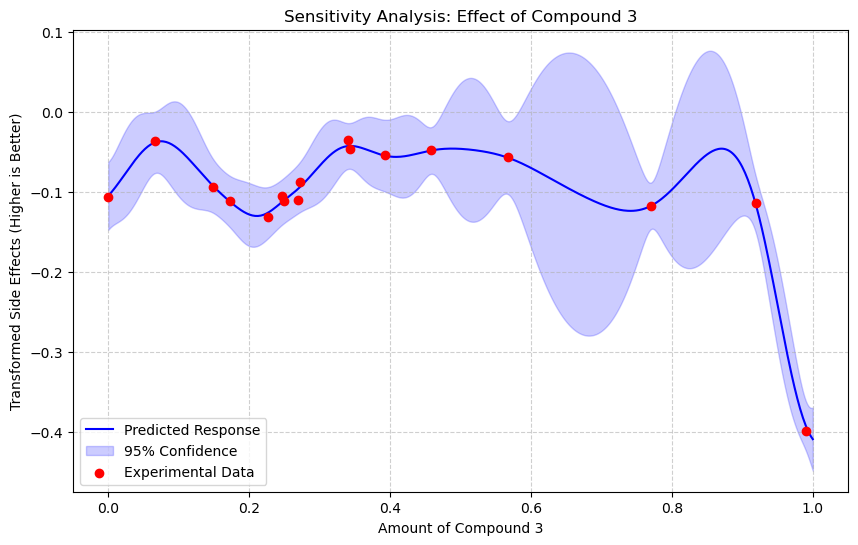

In [16]:
import matplotlib.pyplot as plt

# 1. Create a "slice" across the Compound 3 dimension (Index 2)
# Hold Compounds 1 and 2 at the values found by your optimizer
base_combination = res.x.copy()
resolution = 500
c3_range = np.linspace(0, 1, resolution)

# Create a grid where only C3 changes
test_grid = np.tile(base_combination, (resolution, 1))
test_grid[:, 2] = c3_range

# 2. Predict mean and uncertainty
mu, std = model.predict(test_grid, return_std=True)

# 3. Plotting
plt.figure(figsize=(10, 6))
plt.plot(c3_range, mu, label='Predicted Response', color='blue')
plt.fill_between(c3_range, mu - 1.96*std, mu + 1.96*std, alpha=0.2, color='blue', label='95% Confidence')
plt.scatter(X[:, 2], Y, color='red', label='Experimental Data', zorder=5)
plt.title('Sensitivity Analysis: Effect of Compound 3')
plt.xlabel('Amount of Compound 3')
plt.ylabel('Transformed Side Effects (Higher is Better)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### Verification that dimensions 1 and 2 should be zero

In [17]:
# Check if moving from 0.0 to 0.5 actually changes anything
test_zero = model.predict(np.array([[0.0, 0.0, 0.659318]]))
test_middle = model.predict(np.array([[0.5, 0.5, 0.659318]]))

print(f"Prediction at (0,0): {test_zero[0]:.6f}")
print(f"Prediction at (0.5, 0.5): {test_middle[0]:.6f}")
print(f"Difference: {abs(test_zero[0] - test_middle[0]):.8f}")

Prediction at (0,0): -0.098827
Prediction at (0.5, 0.5): -0.098672
Difference: 0.00015433


## EI code to ignore

In [11]:
# 3. Vectorized Expected Improvement
def vectorized_ei(x, model, best_y):
    x = x.reshape(-1, n_dims)
    mu, sigma = model.predict(x, return_std=True)
    sigma = sigma.reshape(-1, 1)
    mu = mu.reshape(-1, 1)
    
    # Avoid division by zero
    with np.errstate(divide='ignore'):
        z = (mu - best_y) / sigma
        ei = (mu - best_y) * norm.cdf(z) + sigma * norm.pdf(z)
        ei[sigma <= 0] = 0.0
    return ei.flatten()

In [12]:
# 4. Global Search (Vectorized) using Expected Improvement   - IGNORE
current_best_y = np.max(Y)
num_candidates = 100000 
x_candidates = np.random.uniform(0, 1, size=(num_candidates, n_dims))

# Evaluate all at once - much faster!
ei_values = vectorized_ei(x_candidates, model, current_best_y)
x_start = x_candidates[np.argmax(ei_values)]

# 5. Local Polish
res = minimize(
    lambda x: -vectorized_ei(x, model, current_best_y)[0],
    x0=x_start, 
    bounds=[(0, 1)] * n_dims, 
    method='L-BFGS-B' )

# Output
formatted_submission = "-".join(f"{val:.6f}" for val in res.x)
print(f"Submit this: {formatted_submission}")
print(f"Predicted Y: {model.predict(res.x.reshape(1, -1))[0]:.4f}")

Submit this: 1.000000-0.890675-0.859739
Predicted Y: -0.0475


## Matern Kernel

In [7]:
n_dims = X.shape[1]
Matern_kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=[0.5] * X.shape[1], 
                          length_scale_bounds=(1e-2, 2.0),      # Cap at 2.0 to force local relevance
                          nu=2.5         
                          ) + WhiteKernel(noise_level=1e-3, 
                          noise_level_bounds=(1e-5, 0.1))

model = GaussianProcessRegressor(
    kernel=Matern_kernel,
    # alpha=0,               # Let WhiteKernel handle the noise instead
    normalize_y=True,        # CRITICAL: This scales those tiny e-124 values so the GP can see them
    n_restarts_optimizer=30)   # Gives the optimizer N tries to find the best fit
# 3. Fit the model
model.fit(X, Y)
print(f"Optimized Kernel: {model.kernel_}")

Optimized Kernel: 1.15**2 * Matern(length_scale=[2, 2, 0.0662], nu=2.5) + WhiteKernel(noise_level=0.0111)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [8]:
from scipy.optimize import minimize
from scipy.stats import norm

def expected_improvement(x, model, best_y):
    mu, sigma = model.predict(x.reshape(1, -1), return_std=True)
    if sigma <= 0: return 0
    # We want to exceed our current best (maximized negative side effects)
    z = (mu - best_y) / sigma
    ei = (mu - best_y) * norm.cdf(z) + sigma * norm.pdf(z)
    return ei[0]

# 3. GLOBAL SEARCH + LOCAL POLISH
current_best_y = np.max(Y)
num_candidates = 50000
x_candidates = np.random.uniform(0, 1, size=(num_candidates, n_dims))

# Evaluate EI on candidates
ei_values = np.array([expected_improvement(c, model, current_best_y) for c in x_candidates])
x_start = x_candidates[np.argmax(ei_values)]

# Polisher
res = minimize(
    lambda x: -expected_improvement(x, model, current_best_y),
    x0=x_start, 
    bounds=[(0, 1)] * n_dims, 
    method='L-BFGS-B'
)

formatted_submission_string = "-".join(f"{val:.6f}" for val in res.x)
print(f"Submit this: {formatted_submission_string}")

y_predicted = model.predict(res.x.reshape(1, -1))[0]
print(f"Predicted Y is {model.predict(res.x.reshape(1,-1))[0]:.4f} ")


Submit this: 1.000000-1.000000-0.499819
Predicted Y is -0.0562 


results:
Submit this: 1.000000-1.000000-0.499819
Predicted Y is -0.0562


In [103]:
num = 1

for i in range(0, num):
    print("count")

count
